In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def FTBS(a, Cr, T, Nx, xmin, xmax):
    dx = (xmax - xmin) / Nx
    x = np.linspace(xmin, xmax, Nx, endpoint=False)

    dt = Cr * dx / a
    Nt = int(T / dt)
    dt = T / Nt        # adjust dt so final time is exact
    Cr = a * dt / dx

    # Allocate solution array
    u = np.zeros((Nt+1, Nx))

    # Initial condition
    u[0, :] = np.sin(2*np.pi*x)

    # FTBS scheme
    for n in range(Nt):
        for j in range(Nx):

            # periodic boundary condition
            jm1 = (j - 1) % Nx

            u[n+1, j] = (
                u[n, j]
                - Cr * (u[n, j] - u[n, jm1])
            )
        
    return u, dt, dx

dx = 0.02
dt = 0.03225806451612903
CFL = 0.8
Max error = 0.03746704951811275


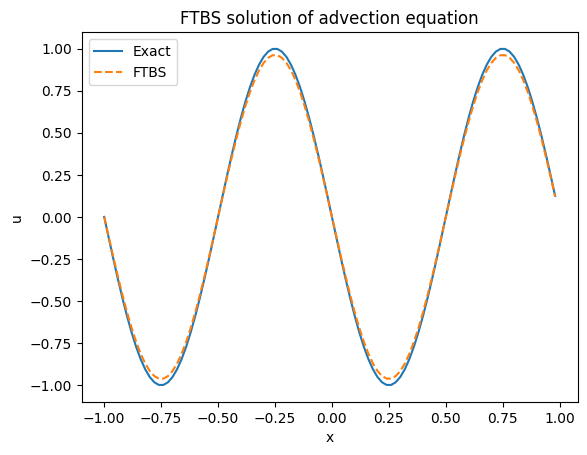

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
a = 0.5
xmin, xmax = -1.0, 1.0
T = 1.0 # final time
Nx = 100
Cr = 0.8 


# Approximate solution
u, dt, dx = FTBS(a, Cr, T, Nx, xmin, xmax)

# Exact solution
dx = (xmax - xmin) / Nx
x = np.linspace(xmin, xmax, Nx, endpoint=False)

uexact = np.sin(2*np.pi*(x - a*T))

# Error
error = np.max(np.abs(u[-1,:] - uexact))

print("dx =", dx)
print("dt =", dt)
print("CFL =", Cr)
print("Max error =", error)

# Plot
plt.plot(x, uexact, label="Exact")
plt.plot(x, u[-1,:], '--', label="FTBS")
plt.xlabel("x")
plt.ylabel("u")
plt.legend()
plt.title("FTBS solution of advection equation")
plt.show()

In [4]:
Nx_values = [25, 50, 100, 200, 400, 800, 1600]

dx_errors = []
dx_values = []

for Nx in Nx_values:
    

    u, dt, dx = FTBS(a, Cr, T, Nx, xmin, xmax)

    x = np.linspace(xmin, xmax, Nx, endpoint=False)

    # exact solution
    u_exact = np.sin(2*np.pi*(x - a*T))

    # max norm error
    error = np.max(np.abs(u[-1,:] - u_exact))

    dx_errors.append(error)
    dx_values.append(dx)


Nt_values = [50, 100, 200, 400, 800, 1600]

dt_errors = []
dt_values = []

L = xmax - xmin

for Nt in Nt_values:

    # choose dt
    dt = T / Nt

    # compute dx from CFL condition
    dx = a * dt / Cr

    # corresponding Nx
    Nx = int(L / dx)

    # run solver
    u, dt, dx = FTBS(a, Cr, T, Nx, xmin, xmax)

    x = np.linspace(xmin, xmax, Nx, endpoint=False)

    # exact solution
    u_exact = np.sin(2*np.pi*(x - a*T))

    # error
    error = np.max(np.abs(u[-1,:] - u_exact))

    dt_errors.append(error)
    dt_values.append(dt)

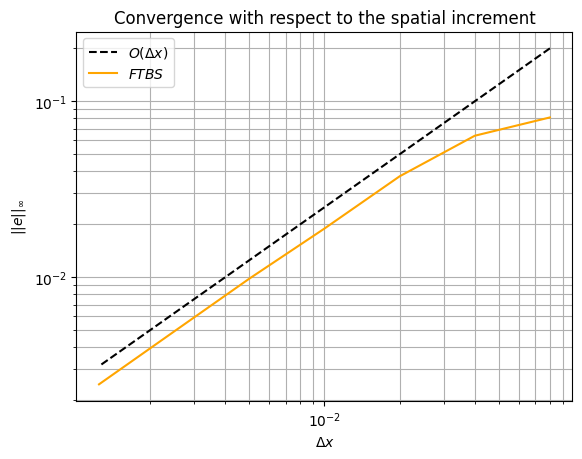

array([0.99733089, 0.66115175])

In [5]:
plt.loglog(dx_values,2.5*np.array(dx_values), 'k--', label=r"$O(\Delta x)$")
plt.loglog(dx_values,dx_errors,color="orange", label=r"$FTBS$")
plt.title("Convergence with respect to the spatial increment")
plt.xlabel(r'$\Delta x$')
plt.ylabel(r'$||e||_\infty$')
plt.grid(True, which = 'both')
plt.legend()
plt.show()

np.polyfit(np.log(dx_values[4:]),np.log(dx_errors[4:]),1)

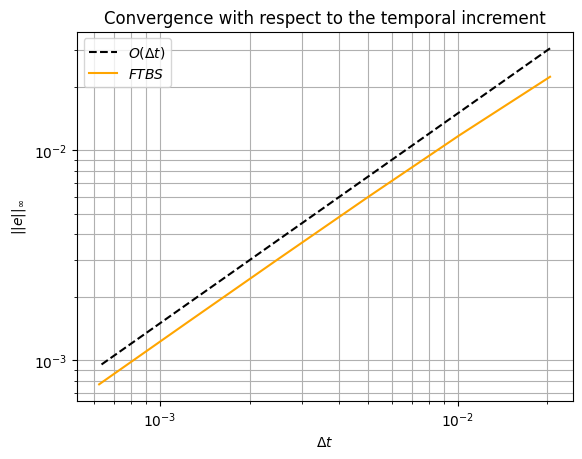

array([0.99237018, 0.15080806])

In [6]:
plt.loglog(dt_values,1.5*np.array(dt_values), 'k--', label=r"$O(\Delta t)$")
plt.loglog(dt_values,dt_errors,color="orange", label=r"$FTBS$")
plt.title("Convergence with respect to the temporal increment")
plt.xlabel(r'$\Delta t$')
plt.ylabel(r'$||e||_\infty$')
plt.grid(True, which = 'both')
plt.legend()
plt.show()

np.polyfit(np.log(dt_values[3:]),np.log(dt_errors[3:]),1)

In [12]:
theta = 2*np.pi/100
Cr = 0.8
g = np.sqrt(1+2*Cr*(1-Cr)*(np.cos(theta)-1))
g**(5000)

0.20615728671621153

In [22]:
phi = -np.arctan(Cr*np.sin(theta)/(1-Cr+Cr*np.cos(theta)))+Cr*theta
phi,5000*phi

(-3.969524197969254e-06, -0.01984762098984627)

In [24]:
(5000*phi)/(2*np.pi)

-0.003158846989148491

dx = 0.01
dt = 0.016
CFL = 0.8
Number of time steps = 5000
Max error = 0.7938833175206765


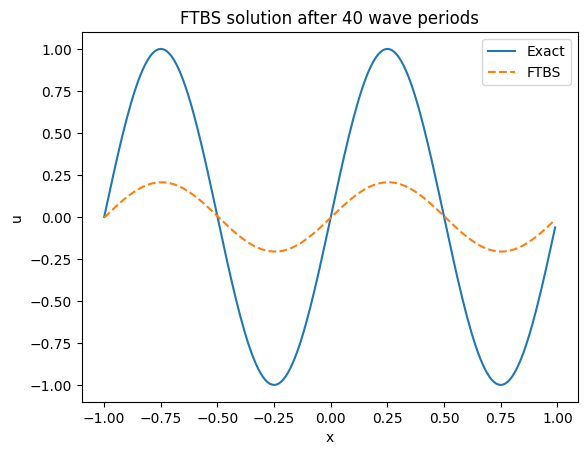

In [26]:
# Parameters
a = 0.5
xmin, xmax = -1.0, 1.0

# 100 points per wavelength
Nx = 200                     # domain length is 2, wavelength is 1
Cr = 0.8

# 40 wave periods
wave_period = 1 / a          # T = wavelength / a, wavelength = 1
T = 40 * wave_period


# Approximate solution
u, dt, dx = FTBS(a, Cr, T, Nx, xmin, xmax)

# Exact solution
x = np.linspace(xmin, xmax, Nx, endpoint=False)

# After an integer number of periods, exact solution = initial condition
uexact = np.sin(2*np.pi*x)

# Error
error = np.max(np.abs(u[-1,:] - uexact))

print("dx =", dx)
print("dt =", dt)
print("CFL =", Cr)
print("Number of time steps =", len(u)-1)
print("Max error =", error)

# Plot
plt.plot(x, uexact, label="Exact")
plt.plot(x, u[-1,:], '--', label="FTBS")
plt.xlabel("x")
plt.ylabel("u")
plt.legend()
plt.title("FTBS solution after 40 wave periods")
plt.show()

In [37]:
T

80.0

In [36]:
np.max(u[-1,:])

0.20611668247932358